In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import joblib
import seaborn as sns
import matplotlib.pyplot as plt



In [37]:
from scipy.stats import chi2_contingency

In [43]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [3]:
df = pd.read_csv('Obesity.csv')

In [4]:
df.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [41]:
df.dtypes

Gender             object
Age               float64
Height            float64
Weight            float64
family_history     object
FAVC               object
FCVC                int64
NCP                 int64
CAEC               object
SMOKE              object
CH2O                int64
SCC                object
FAF                 int64
TUE                 int64
CALC               object
MTRANS             object
Obesity            object
IMC               float64
Obeso_bin           int64
dtype: object

In [28]:
df.isnull().sum()

# "A base não apresentou valores ausentes, não sendo necessário tratamento de imputação."# 

Gender            0
Age               0
Height            0
Weight            0
family_history    0
FAVC              0
FCVC              0
NCP               0
CAEC              0
SMOKE             0
CH2O              0
SCC               0
FAF               0
TUE               0
CALC              0
MTRANS            0
Obesity           0
IMC               0
Obeso_bin         0
dtype: int64

In [7]:
df.duplicated().sum()

#"Foram identificados 24 registros duplicados. 
# Considerando que a base não possui identificador único de paciente, 
# optou-se por manter os registros, assumindo que indivíduos diferentes 
# podem compartilhar as mesmas características."

np.int64(24)

In [8]:
# =====================================================
# ANÁLISE EXPLORATÓRIA DE DADOS (EDA)
# Avaliação de balanceamento da variável alvo
# =====================================================

counts = df['Obesity'].value_counts()
tot = counts.sum()

obese_classes = ['Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']

obesos = counts[obese_classes].sum()
nao_obesos = counts.drop(obese_classes).sum()

print("Obesos (%):", round((obesos/tot)*100, 2))
print("Não obesos (%):", round((nao_obesos/tot)*100, 2))

Obesos (%): 46.04
Não obesos (%): 53.96


In [9]:
df.shape

(2111, 17)

In [ ]:
# =====================================================
# FEATURE ENGINEERING
# AJUSTANDO TIPOS PRIMITIVOS
# =====================================================

df['IMC'] = df['Weight'] / (df['Height'] ** 2)

cols_to_round = ['FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

for col in cols_to_round:
    df[col] = df[col].round().astype(int)

In [26]:
obese_classes = ['Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']
df['Obeso_bin'] = df['Obesity'].apply(lambda x: 1 if x in obese_classes else 0)

In [10]:
# =====================================================
# ANÁLISE EXPLORATÓRIA DE DADOS (EDA)
# IDENTIFICANDO OPORTUNIDADES
# =====================================================

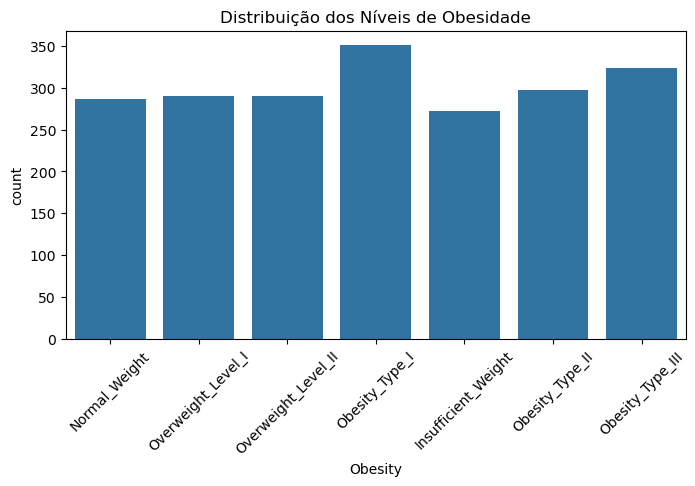

In [11]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='Obesity')
plt.xticks(rotation=45)
plt.title("Distribuição dos Níveis de Obesidade")
plt.show()

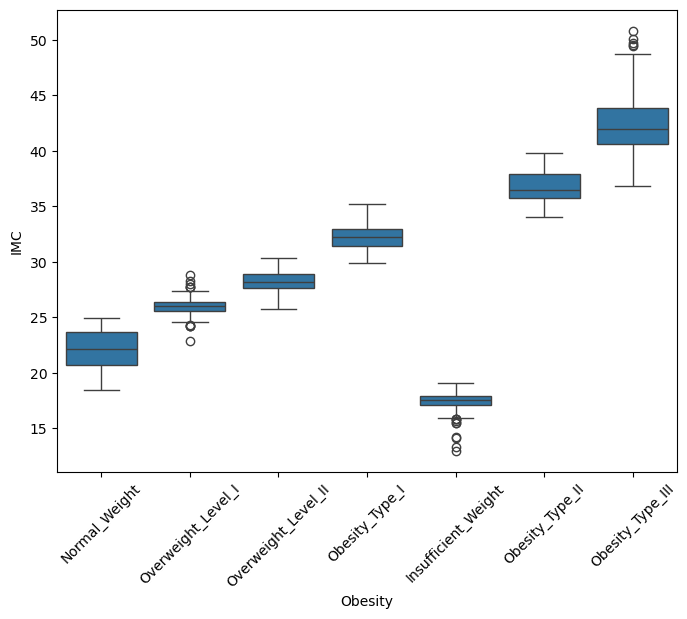

In [15]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='Obesity', y='IMC')
plt.xticks(rotation=45)
plt.show()

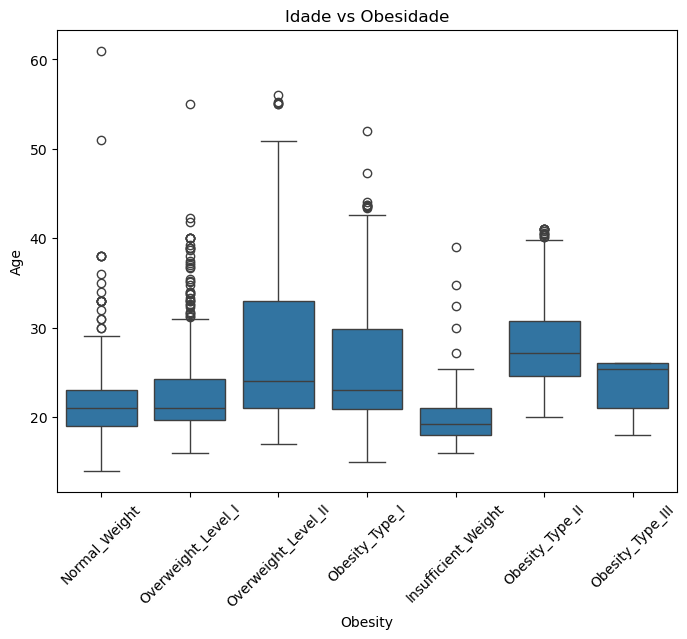

In [27]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='Obesity', y='Age')
plt.title("Idade vs Obesidade")
plt.xticks(rotation=45)
plt.show()

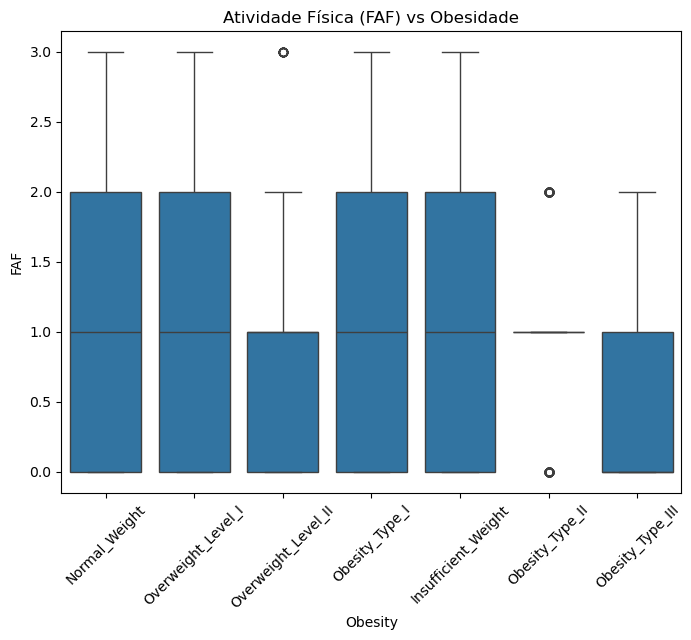

In [28]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='Obesity', y='FAF')
plt.title("Atividade Física (FAF) vs Obesidade")
plt.xticks(rotation=45)
plt.show()

In [42]:
table = (pd.crosstab(df['family_history'], df['Obesity'], normalize='index')*100).round(2)
table.astype(str) + '%'
#A associação entre histórico familiar e obesidade pode refletir não apenas predisposição genética, 
# mas também padrões alimentares e comportamentais compartilhados no ambiente familiar.

Obesity,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
family_history,,,,,,,
no,37.92%,34.29%,1.82%,0.26%,0.0%,21.04%,4.68%
yes,7.3%,8.98%,19.93%,17.15%,18.77%,12.11%,15.76%


In [16]:
table = (pd.crosstab(df['FCVC'], df['Obesity'], normalize='index')*100).round(2)
table.astype(str) + '%'
#) Frequência de consumo de vegetais nas refeições. Valores (escala 1–3):
# 1 raramente, 2 às vezes, 3 sempre. 


Obesity,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
FCVC,,,,,,,
1,22.55%,17.65%,16.67%,20.59%,0.0%,13.73%,8.82%
2,8.49%,15.3%,25.27%,13.62%,0.0%,18.36%,18.95%
3,16.37%,11.45%,7.83%,13.86%,32.53%,9.04%,8.94%


In [17]:
# Número de refeições principais por dia. Valores (escala 1–4): 
# 1 uma refeição, 2 duas, 3 três, 4 quatro ou mais

table = (pd.crosstab(df['NCP'], df['Obesity'], normalize='index')*100).round(2)
table.astype(str) + '%'

Obesity,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
NCP,,,,,,,
1,11.71%,16.46%,25.0%,7.59%,0.0%,24.05%,15.19%
2,10.23%,0.0%,26.7%,20.45%,0.0%,13.07%,29.55%
3,9.86%,14.01%,15.31%,15.51%,22.04%,10.75%,12.52%
4,48.32%,19.46%,0.0%,6.04%,0.0%,22.15%,4.03%


In [18]:
#  Consumo de lanches/comes entre as refeições. Valores: no (não consome), Sometimes (às vezes),
# Frequently (frequentemente), Always (sempre).

table = (pd.crosstab(df['CAEC'], df['Obesity'], normalize='index')*100).round(2)
table.astype(str) + '%'

Obesity,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
CAEC,,,,,,,
Always,3.77%,66.04%,11.32%,3.77%,0.0%,9.43%,5.66%
Frequently,50.0%,34.3%,2.48%,0.41%,0.41%,5.79%,6.61%
Sometimes,8.27%,9.01%,19.15%,16.6%,18.3%,13.37%,15.3%
no,5.88%,19.61%,1.96%,1.96%,0.0%,68.63%,1.96%


In [19]:
#  (Smoking) Hábito de fumar. Valores: yes (fuma), no (não fuma).

table = (pd.crosstab(df['SMOKE'], df['Obesity'], normalize='index')*100).round(2)
table.astype(str) + '%'

Obesity,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
SMOKE,,,,,,,
no,13.11%,13.26%,16.69%,13.64%,15.63%,13.88%,13.79%
yes,2.27%,29.55%,13.64%,34.09%,2.27%,6.82%,11.36%


In [20]:
#  Consumo diário de água. Valores (escala 1–3): 
# 1 < 1 L/dia, 2 1–2 L/dia, 3 > 2 L/dia.

table = (pd.crosstab(df['CH2O'], df['Obesity'], normalize='index')*100).round(2)
table.astype(str) + '%'

Obesity,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
CH2O,,,,,,,
1,17.32%,17.11%,14.02%,16.91%,12.58%,12.37%,9.69%
2,12.79%,14.77%,15.59%,15.95%,10.27%,13.87%,16.76%
3,8.91%,7.75%,21.32%,7.36%,28.88%,14.73%,11.05%


In [21]:
#  Monitora a ingestão calórica diária. Valores: Valores: yes (sim), no (não) 

table = (pd.crosstab(df['SCC'], df['Obesity'], normalize='index')*100).round(2)
table.astype(str) + '%'

Obesity,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
SCC,,,,,,,
no,12.41%,12.75%,17.32%,14.69%,16.08%,12.56%,14.19%
yes,22.92%,31.25%,2.08%,1.04%,0.0%,38.54%,4.17%


In [22]:
#  Frequência semanal de atividade física. Valores (escala 0–3): 
# 0 nenhuma, 1 ~1–2×/sem, 2 ~3–4×/sem, 3 5×/sem ou

table = (pd.crosstab(df['FAF'], df['Obesity'], normalize='index')*100).round(2)
table.astype(str) + '%'

Obesity,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
FAF,,,,,,,
0,10.0%,11.11%,18.19%,9.58%,25.97%,11.67%,13.47%
1,9.28%,12.5%,15.85%,21.26%,8.76%,16.24%,16.11%
2,23.59%,13.91%,14.52%,12.7%,13.91%,11.29%,10.08%
3,9.24%,34.45%,21.01%,0.0%,0.0%,20.17%,15.13%


In [23]:
#  Tempo diário usando dispositivos eletrônicos. 
# Valores (escala 0–2): 0 ~0–2 h/dia, 1 ~3–5 h/dia, 2 > 5 h/dia.

table = (pd.crosstab(df['TUE'], df['Obesity'], normalize='index')*100).round(2)
table.astype(str) + '%'

Obesity,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
TUE,,,,,,,
0,9.87%,13.55%,17.75%,18.17%,11.45%,17.23%,11.97%
1,13.88%,13.33%,13.22%,11.26%,23.5%,8.96%,15.85%
2,20.9%,14.75%,25.0%,8.61%,0.0%,18.03%,12.7%


In [25]:
#  Consumo de bebida alcoólica. Valores: 
# no (não bebe), Sometimes (às vezes), Frequently (frequentemente), Always

table = (pd.crosstab(df['Obesity'], df['CALC'], normalize='index')*100).round(2)
table.astype(str) + '%'

CALC,Always,Frequently,Sometimes,no
Obesity,,,,
Insufficient_Weight,0.0%,0.37%,56.62%,43.01%
Normal_Weight,0.35%,6.27%,56.1%,37.28%
Obesity_Type_I,0.0%,3.99%,49.0%,47.01%
Obesity_Type_II,0.0%,0.67%,75.42%,23.91%
Obesity_Type_III,0.0%,0.0%,99.69%,0.31%
Overweight_Level_I,0.0%,5.52%,77.24%,17.24%
Overweight_Level_II,0.0%,6.55%,49.31%,44.14%


In [27]:
(pd.crosstab(df['CALC'], df['Obeso_bin'], normalize='index')*100).round(2)

Obeso_bin,0,1
CALC,,
Always,100.00,0.00
Frequently,77.14,22.86
Sometimes,48.68,51.32
no,62.91,37.09


In [32]:
#Cigarro

(pd.crosstab(df['SMOKE'], df['Obeso_bin'], normalize='index') * 100).round(2)

Obeso_bin,0,1
SMOKE,,
no,54.04,45.96
yes,50.00,50.00


In [33]:
# Comida calórica (essa costuma ser relevante)

(pd.crosstab(df['FAVC'], df['Obeso_bin'], normalize='index') * 100).round(2)

Obeso_bin,0,1
FAVC,,
no,92.24,7.76
yes,48.93,51.07


In [40]:
(pd.crosstab(df['FAVC'], df['Obeso_bin'], normalize='columns') * 100).round(2)

Obeso_bin,0,1
FAVC,,
no,19.84,1.95
yes,80.16,98.05


In [36]:
# Tempo de tela (TUE)
(pd.crosstab(df['TUE'], df['Obeso_bin'], normalize='index') * 100).round(2)

Obeso_bin,0,1
TUE,,
0,52.63,47.37
1,52.02,47.98
2,66.39,33.61


In [39]:
cont = pd.crosstab(df['FAVC'], df['Obeso_bin'])
chi2, p, dof, expected = chi2_contingency(cont)

print("===== Teste Qui-Quadrado =====")
print(f"Estatística Qui² : {chi2:.2f}")
print(f"Graus de liberdade: {dof}")
print(f"P-valor           : {p:.5e}")

===== Teste Qui-Quadrado =====
Estatística Qui² : 161.82
Graus de liberdade: 1
P-valor           : 4.51831e-37


In [ ]:
#O teste Qui-Quadrado indicou associação estatisticamente significativa entre consumo frequente de alimentos 
# altamente calóricos e obesidade (χ² = 161.82; p < 0.001). 
# Contudo, a análise não permite inferir causalidade direta.

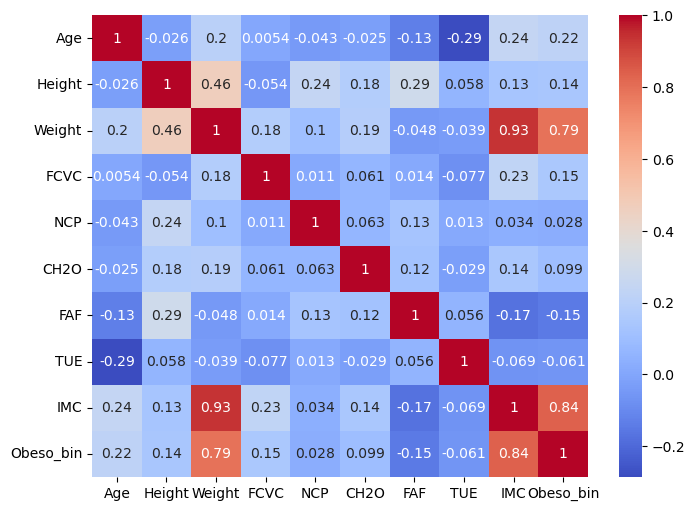

In [34]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

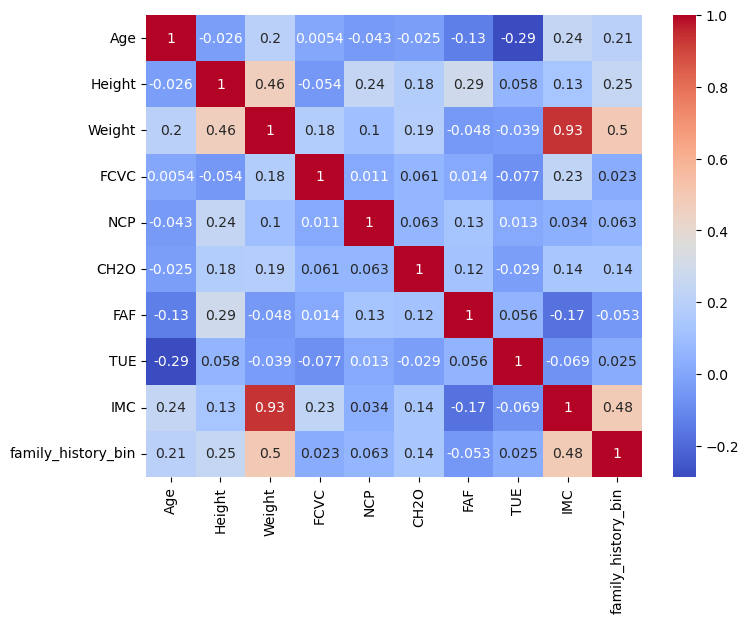

In [35]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [45]:
df.dtypes

Gender             object
Age               float64
Height            float64
Weight            float64
family_history     object
FAVC               object
FCVC                int64
NCP                 int64
CAEC               object
SMOKE              object
CH2O                int64
SCC                object
FAF                 int64
TUE                 int64
CALC               object
MTRANS             object
Obesity            object
IMC               float64
Obeso_bin           int64
dtype: object

In [46]:
df.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity,IMC,Obeso_bin
0,Female,21.0,1.62,64.0,yes,no,2,3,Sometimes,no,2,no,0,1,no,Public_Transportation,Normal_Weight,24.386526,0
1,Female,21.0,1.52,56.0,yes,no,3,3,Sometimes,yes,3,yes,3,0,Sometimes,Public_Transportation,Normal_Weight,24.238227,0
2,Male,23.0,1.80,77.0,yes,no,2,3,Sometimes,no,2,no,2,1,Frequently,Public_Transportation,Normal_Weight,23.765432,0
3,Male,27.0,1.80,87.0,no,no,3,3,Sometimes,no,2,no,2,0,Frequently,Walking,Overweight_Level_I,26.851852,0
4,Male,22.0,1.78,89.8,no,no,2,1,Sometimes,no,2,no,0,0,Sometimes,Public_Transportation,Overweight_Level_II,28.342381,0


In [68]:
X = df.drop(['Obesity', 'Obeso_bin'], axis=1)
y = df['Obeso_bin']

In [69]:
numerical_cols = [
    'Age','Height','Weight',
    'FCVC','NCP','CH2O','FAF','TUE'
]

categorical_cols = [
    'Gender','family_history','FAVC',
    'CAEC','SMOKE','SCC','CALC','MTRANS'
]

In [70]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ]
)

In [71]:
model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

In [72]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', model)
])

In [73]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [74]:
pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [75]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy*100,2), "%")
print(classification_report(y_test, y_pred))

Accuracy: 98.58 %
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       228
           1       0.98      0.98      0.98       195

    accuracy                           0.99       423
   macro avg       0.99      0.99      0.99       423
weighted avg       0.99      0.99      0.99       423



c:\ProgramData\anaconda3\envs\ML\lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


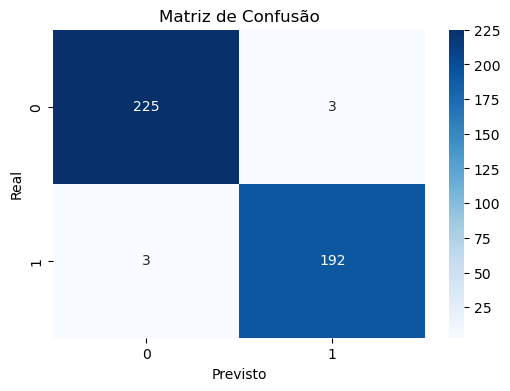

In [76]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()

In [61]:
df = df.drop('IMC', axis=1)

In [77]:
import joblib

joblib.dump(pipeline, "modelo_obesidade.pkl")

['modelo_obesidade.pkl']